# 0. QC

In [1]:
import os
import sys
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_pipeline_qc
from tqdm import tqdm
import pandas as pd


tomonth=12


pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"


for dataset_name in ['BCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants_selected_30_eachbin.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    qc_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/QC"
    subs_qc = pd.read_csv(os.path.join(qc_dir, f"{dataset_name}_first{tomonth}M_registration_check.csv"), sep=',')
    subs_qc = subs_qc.subid.drop_duplicates().to_list()
    print(f"Subjects passed QC for registration: {len(subs_qc)} \n{subs_qc}")
    for m_bin in window_cols[:tomonth]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
        print(f'Tpl month: {tpl_months}')


        for tpl_month in tpl_months:
            print(f"Running registration → tpl_month={tpl_month}")

            for subid in subs[m_bin]:
                if subid in subs_qc:
                    output_dir = os.path.join(pipel_dir, dataset_name, subid)
                    input_files = {
                        "T1": f"{output_dir}/T1_Brain_pad.nii.gz",
                        "T2": f"{output_dir}/T2_Brain_pad.nii.gz"
                    }

                    multimodal_register_pipeline_qc(
                        modalities=["T1", "T2"],
                        input_files=input_files,
                        tpl_root=tpl_root,
                        tpl_month=tpl_month,
                        output_dir=output_dir,
                        slurm=True
                    )

Processing dataset: BCP
Subjects passed QC for registration: 68 
['sub-015', 'sub-018', 'sub-021', 'sub-022', 'sub-023', 'sub-030', 'sub-032', 'sub-033', 'sub-042', 'sub-056', 'sub-076', 'sub-093', 'sub-105', 'sub-110', 'sub-123', 'sub-127', 'sub-130', 'sub-134', 'sub-135', 'sub-158', 'sub-160', 'sub-167', 'sub-169', 'sub-173', 'sub-161', 'sub-179', 'sub-183', 'sub-184', 'sub-185', 'sub-194', 'sub-204', 'sub-213', 'sub-218', 'sub-221', 'sub-229', 'sub-236', 'sub-245', 'sub-248', 'sub-249', 'sub-253', 'sub-262', 'sub-266', 'sub-273', 'sub-247', 'sub-252', 'sub-261', 'sub-275', 'sub-276', 'sub-277', 'sub-278', 'sub-279', 'sub-280', 'sub-284', 'sub-290', 'sub-293', 'sub-294', 'sub-303', 'sub-307', 'sub-309', 'sub-310', 'sub-311', 'sub-313', 'sub-323', 'sub-328', 'sub-334', 'sub-336', 'sub-343', 'sub-347']
Subjects in age bin 0-1M: 21
Tpl month: ['00', '01']
Running registration → tpl_month=00
Running registration → tpl_month=01
Subjects in age bin 1-2M: 27
Tpl month: ['01', '02']
Running 

# 1. Lesion
Generate lesion mask by fsleyes in individual space
-> Block the T1_Brain and T2_Brain img
-> Registration with or sithou mask

In [21]:
# Block the T1_Brain and T2_Brain img
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_pipeline
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)

lesion_mask = nib.load(os.path.join(output_dir,"lesion_mask.nii.gz"))
T1_Brain = nib.load(os.path.join(output_dir,"T1_Brain_pad.nii.gz"))
T2_Brain = nib.load(os.path.join(output_dir,"T2_Brain_pad.nii.gz"))
T1_data = T1_Brain.get_fdata()
T2_data = T2_Brain.get_fdata()
lesion_data = lesion_mask.get_fdata()

T1_data[lesion_data == 1] = 0
T2_data[lesion_data == 1] = 0

T1_Brain_new = nib.Nifti1Image(T1_data, affine=T1_Brain.affine, header=T1_Brain.header)
T2_Brain_new = nib.Nifti1Image(T2_data, affine=T2_Brain.affine, header=T2_Brain.header)

nib.save(T1_Brain_new, os.path.join(output_dir, "T1_Brain_pad_lesion.nii.gz"))
nib.save(T2_Brain_new, os.path.join(output_dir, "T2_Brain_pad_lesion.nii.gz"))


In [22]:
# Generate the moving mask
T1_data[T1_data > 0] = 1
T1_data[lesion_data == 1] = 0
T1_Brain_mask = nib.Nifti1Image(T1_data, affine=T1_Brain.affine, header=T1_Brain.header)
nib.save(T1_Brain_mask, os.path.join(output_dir, "T1_Brain_pad_lesion_mask.nii.gz"))

T2_data[T2_data > 0] = 1
T2_data[lesion_data == 1] = 0
T2_Brain_mask = nib.Nifti1Image(T2_data, affine=T2_Brain.affine, header=T2_Brain.header)
nib.save(T2_Brain_mask, os.path.join(output_dir, "T2_Brain_pad_lesion_mask.nii.gz"))

In [1]:
# Registration with or without mask
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)

tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
tpl_months = ['00','01']
for tpl_month in tpl_months:
    print(f"Running registration → tpl_month={tpl_month}")
    input_files = {
        "T1": f"{output_dir}/T1_Brain_pad_lesion.nii.gz",
        "T2": f"{output_dir}/T2_Brain_pad_lesion.nii.gz"
    }


    multimodal_register_lesion_pipel(
        modalities=["T1", "T2"],
        input_files=input_files,
        tpl_root=tpl_root,
        tpl_month=tpl_month,
        output_dir=output_dir,
        slurm=True
    )

Running registration → tpl_month=00
[INFO] Using default subject moving mask
[INFO] No moving mask used
[INFO] Submitting job: les_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51636437
[INFO] Job ID: 51636437
Running registration → tpl_month=01
[INFO] Using default subject moving mask
[INFO] No moving mask used
[INFO] Submitting job: les_01Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_01Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-001/log/les_01Mtpl.sh
[INFO] sbatch output: Submitted batch job 51636438
[INFO] Job ID: 51636438


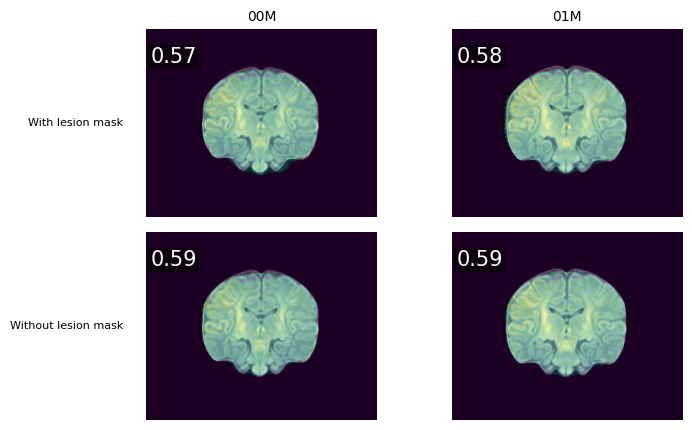

In [7]:
# Show the warped img as the tpl background and calculate the correlation
import os
import sys
import nibabel as nib
import numpy as np
import ants
import matplotlib.pyplot as plt
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
subid = 'sub-001'
output_dir = os.path.join(pipel_dir, dataset_name, subid)   
tpl_months = ['00','01']
tpl_dict = {}
msk_dict = {}
for tpl_month in tpl_months:
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T1.nii.gz"
    )
    mask_file = os.path.join(
            tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-Mask.nii.gz"
        )
    tpl_dict[tpl_month] = ants.image_read(tpl_file).numpy()
    msk_dict[tpl_month] = ants.image_read(mask_file).numpy()

modality_keys = ['withmovmask', 'withoutmovmask']
n_subj = len(modality_keys)
n_cols = len(tpl_months)
fig, axes = plt.subplots(
    n_subj, n_cols,
    figsize=(4 * n_cols, 2.2 * n_subj),
    squeeze=False
)


for i, modality_key in enumerate(modality_keys):
    for j, tpl_month in enumerate(tpl_months):
        registered_img_path = os.path.join(output_dir,f"T1T2_Brain_pad_lesion_Norm_{modality_key}_to_{tpl_month}Mtpl_Warped.nii.gz")
        img_np = ants.image_read(registered_img_path).numpy()
        tpl_np = tpl_dict[tpl_month]

        ax = axes[i, j]
        ax.axis('off')

        sl = np.argmax(img_np.sum(axis=(0,2)))
        sl = img_np.shape[1] // 2
        ax.imshow(tpl_np[:, sl, :].T, cmap='gray', origin='lower' )
        ax.imshow( img_np[:, sl, :].T,cmap='viridis', alpha=0.4,origin='lower')
        # Calculate R and show in left upper corner
        score = np.corrcoef(tpl_np[msk_dict[tpl_month]>0],img_np[msk_dict[tpl_month]>0])[0, 1]
        ax.text(0.22, 0.80,
                f'{score:.2f}',#{eval_mode}=
                transform=ax.transAxes,
                ha='right',
                va='bottom',
                fontsize=15,
                color='white',
                bbox=dict(
                    facecolor='black',
                    alpha=0.5,
                    edgecolor='none',
                    pad=1.5
                ))
        
        # ---------- column titles ----------
        if i == 0:
            ax.set_title(f'{tpl_month}M', fontsize=10)

    # ---------- row labels ----------
    if modality_key == 'withmovmask':
        modality_label = 'With lesion mask'
    else:
        modality_label = 'Without lesion mask'
    axes[i, 0].text(
        -0.1, 0.5,
        modality_label,
        fontsize=8,
        va='center',
        ha='right',
        transform=axes[i, 0].transAxes
    )

plt.tight_layout()
plt.show()


# 2. T1, T2 or combined

In [2]:
# Registration with T1 T2
import os
import sys
import nibabel as nib
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import unimodal_register_pipeline
from tqdm import tqdm
import pandas as pd
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
qc_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/QC"
dataset_name = 'BCP'
info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants_selected_30_eachbin.tsv'), sep='\t')
window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
subs = {}
for w in window_cols:
    subs[w] = (
        info_age.loc[info_age[w], ["participant_id"]]
        .drop_duplicates().values.flatten()
    )
tomonth = 12
subs_qc = pd.read_csv(os.path.join(qc_dir, f"{dataset_name}_first{tomonth}M_registration_check.csv"), sep=',')
subs_qc = subs_qc.subid.drop_duplicates().to_list()

In [4]:
import numpy as np
tomonth=12
for m_bin in window_cols[:tomonth]:
    # print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
    tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
    print(f'Tpl month: {tpl_months}')
    for tpl_month in tpl_months:
        print(f"Running registration → tpl_month={tpl_month}")
        subs_run = subs[m_bin]# [:2]
        # if 'sub-347' in subs[m_bin] and 'sub-347' not in subs_run:
        #     subs_run = np.append(subs_run, 'sub-347')
        # print(f"Subjects to run: {subs_run}")
        for subid in subs_run:  # pick up THE FIRST 2 subjects from each age bin
            if subid in subs_qc:

                print(f"Processing subject: {subid}")
                output_dir = os.path.join(pipel_dir, dataset_name, subid)        
                print(f"Running registration → tpl_month={tpl_month}")
                input_files = {
                    "T1": f"{output_dir}/T1_Brain_pad.nii.gz",
                    "T2": f"{output_dir}/T2_Brain_pad.nii.gz"
                }

                unimodal_register_pipeline(
                    modalities=["T1", "T2", "T1T2"],
                    input_files=input_files,
                    tpl_root=tpl_root,
                    tpl_month=tpl_month,
                    output_dir=output_dir,
                    slurm=True
                )

Tpl month: ['00', '01']
Running registration → tpl_month=00
Processing subject: sub-015
Running registration → tpl_month=00
[INFO] No moving mask used
[INFO] Submitting job: T1o_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-015/log/T1o_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-015/log/T1o_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51707470
[INFO] Job ID: 51707470
[INFO] No moving mask used
[INFO] Submitting job: T2o_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-015/log/T2o_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP/sub-015/log/T2o_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 51707471
[INFO] Job ID: 51707471
[INFO] No moving mask used
[INFO] Submitting job: T1T2o_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/BCP

In [3]:
import os
import sys
import nibabel as nib
import numpy as np
import ants
import matplotlib.pyplot as plt
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_lesion_pipel
from tqdm import tqdm
import pandas as pd
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
dataset_name = 'BCP'
tomonth=12

tpl_dict = {
    'T1': {},
    'T2': {}
}
msk_dict = {}
# to_month = 12
# 0,1,2,...12
to_month = 12
for tpl_month in range(0,to_month+1):
    tpl_month = str(tpl_month).zfill(2)
    # ---- T1 ----
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T1.nii.gz"
    )
    tpl_dict['T1'][tpl_month] = ants.image_read(tpl_file).numpy()

    # ---- T2 ----
    tpl_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T2.nii.gz"
    )
    tpl_dict['T2'][tpl_month] = ants.image_read(tpl_file).numpy()

    # ---- mask ----
    mask_file = os.path.join(
        tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-Mask.nii.gz"
    )
    msk_dict[tpl_month] = ants.image_read(mask_file).numpy()

Tpl month: ['00', '01']
tpl_month=00
tpl_month=01
Tpl month: ['01', '02']
tpl_month=01
tpl_month=02
Tpl month: ['02', '03']
tpl_month=02
tpl_month=03
Tpl month: ['03', '04']
tpl_month=03
tpl_month=04
Tpl month: ['04', '05']
tpl_month=04
tpl_month=05
Tpl month: ['05', '06']
tpl_month=05
tpl_month=06
Tpl month: ['06', '07']
tpl_month=06
tpl_month=07
Tpl month: ['07', '08']
tpl_month=07
tpl_month=08
Tpl month: ['08', '09']
tpl_month=08
tpl_month=09
Tpl month: ['09', '10']
tpl_month=09
tpl_month=10
Tpl month: ['10', '11']
tpl_month=10
tpl_month=11
Tpl month: ['11', '12']
tpl_month=11


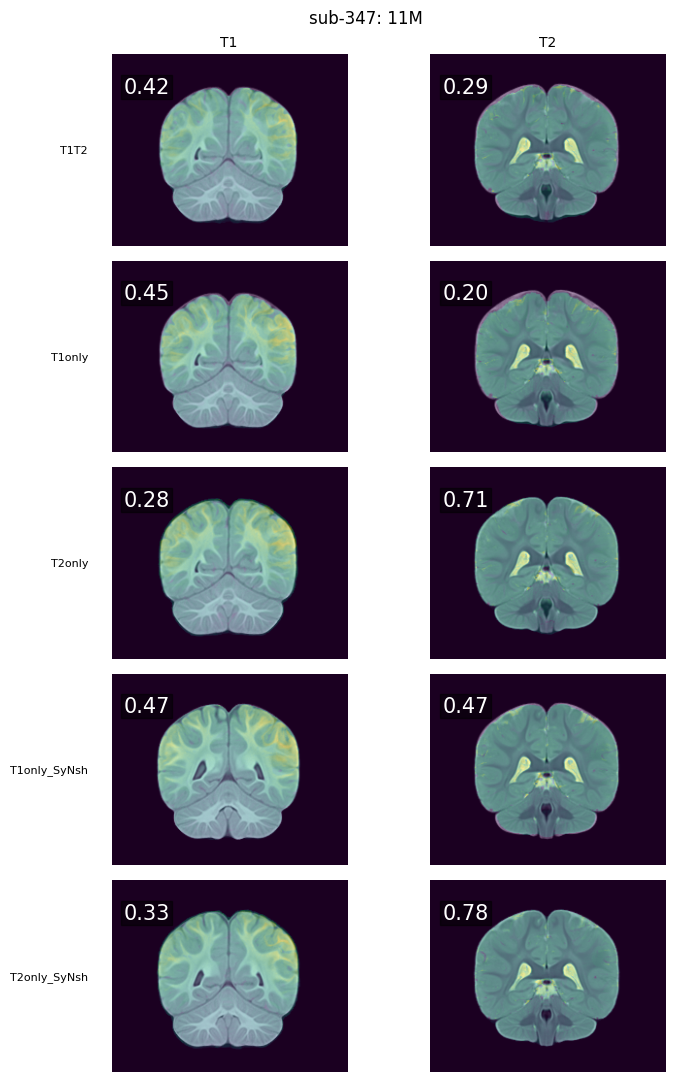

tpl_month=12


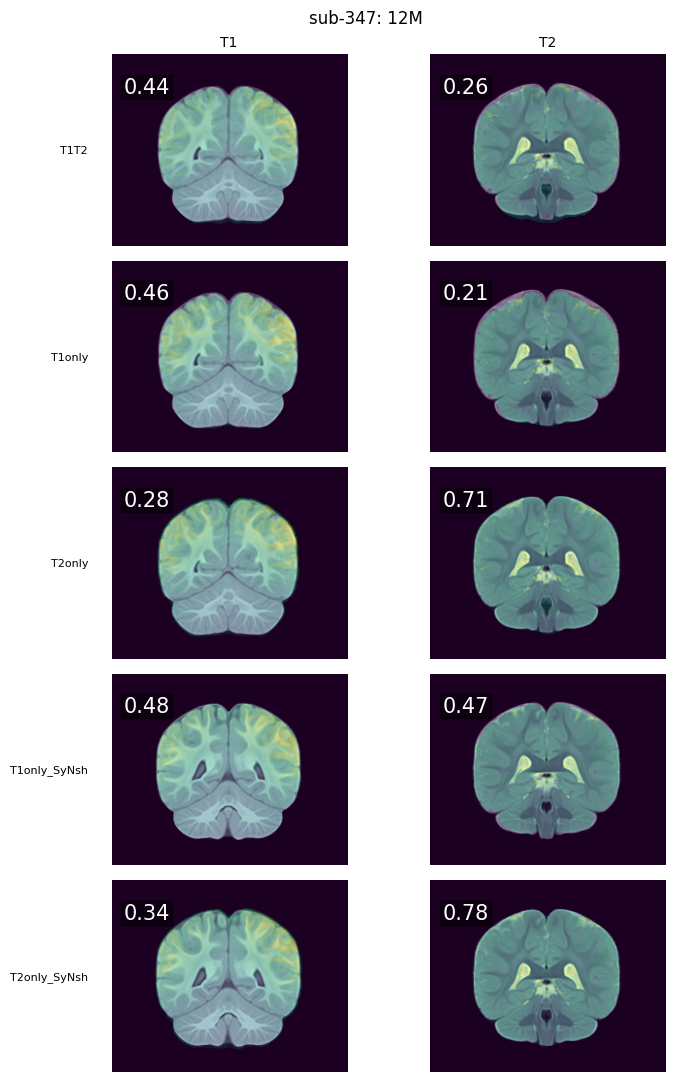

In [9]:
# Show the arped img as the tpl background and calculate the correlation
modality_keys = ['T1', 'T2']
xfm_keys = ['T1T2','T1only', 'T2only','T1only_SyNsh','T2only_SyNsh']
for m_bin in window_cols[:tomonth]:
    # print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
    tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
    print(f'Tpl month: {tpl_months}')
    for tpl_month in tpl_months:
        print(f"tpl_month={tpl_month}")
        for subid in subs[m_bin]: 
            if subid in ['sub-347']:

                output_dir = os.path.join(pipel_dir, dataset_name, subid)   
                fig, axes = plt.subplots(
                    len(xfm_keys), len(modality_keys),
                    figsize=(4 * len(modality_keys), 2.2 * len(xfm_keys)),
                    squeeze=False
                )


                for i, xfm_key in enumerate(xfm_keys):

                    for j, modality_key in enumerate(modality_keys):

                        registered_img_path = os.path.join(
                            output_dir,
                            f"{modality_key}_Brain_pad_resliced_to_{tpl_month}Mtpl_by_{xfm_key}_xfm.nii.gz"
                        )

                        if not os.path.exists(registered_img_path):
                            axes[i, j].axis('off')
                            continue

                        img_np = ants.image_read(registered_img_path).numpy()
                        tpl_np = tpl_dict[modality_key][tpl_month]

                        mask = msk_dict[tpl_month] > 0

                        ax = axes[i, j]
                        ax.axis('off')

                        sl = np.argmax(img_np.sum(axis=(0, 2)))

                        ax.imshow(tpl_np[:, sl, :].T, cmap='gray', origin='lower')
                        ax.imshow(img_np[:, sl, :].T, cmap='viridis', alpha=0.4, origin='lower')

                        score = np.corrcoef(tpl_np[mask],img_np[mask])[0, 1]

                        ax.text(
                            0.05, 0.80,
                            f'{score:.2f}',
                            transform=ax.transAxes,
                            fontsize=15,
                            color='white',
                            bbox=dict(facecolor='black', alpha=0.5, pad=1.5)
                        )

                        if i == 0:
                            ax.set_title(f'{modality_key}', fontsize=10)


                    axes[i, 0].text(
                        -0.1, 0.5,
                        xfm_key,
                        fontsize=8,
                        va='center',
                        ha='right',
                        transform=axes[i, 0].transAxes
                    )
                # title 
                plt.suptitle(f'{subid}: {tpl_month}M', fontsize=12)

                plt.tight_layout()
                plt.show()
